In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
from scipy import signal

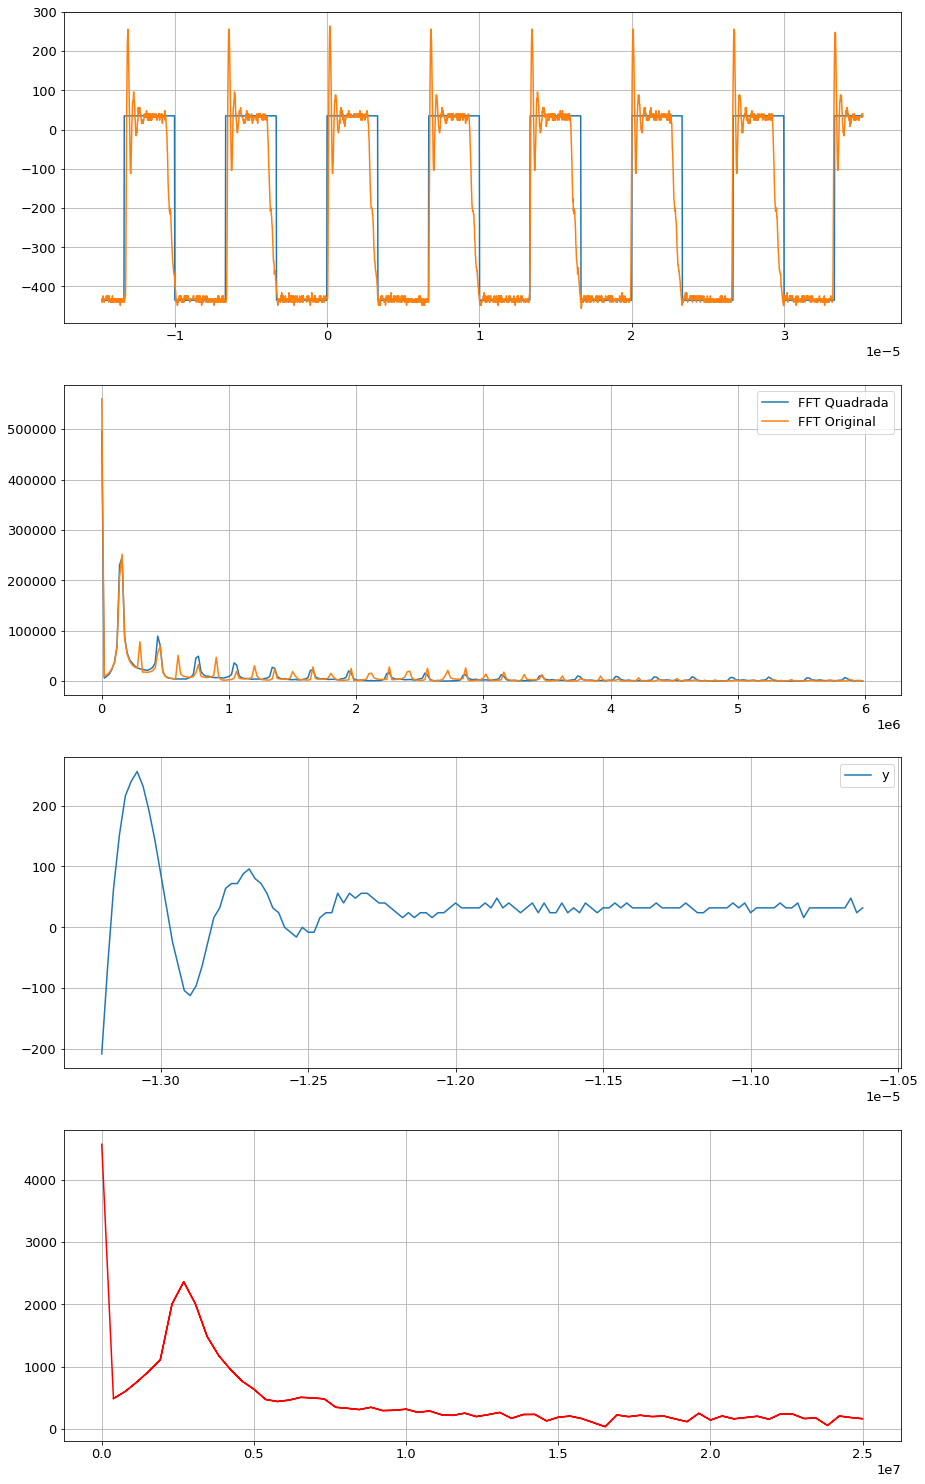

In [39]:
plt.rcParams['figure.figsize'] = [15,40]
plt.rcParams['font.size'] = 13

n = 2500
T = 150e3 * 2 * np.pi
x = np.array(np.linspace(-1.48e-5, 3.518e-5, n))
a = 235
y1 = a * signal.square(x*T) - 200

y_exp = np.loadtxt('curva_original.txt')
t = y_exp[:,0]
y2 = y_exp[:,1]

# Transformada quadrada
fft1 = np.fft.fft(y1)
freqs1 = np.fft.fftfreq(n, t[1] - t[0])

# Transformada original
fft2 = np.fft.fft(y2)
freqs2 = np.fft.fftfreq(n, t[1] - t[0])

plt.subplot(6,2,(1,2))
plt.plot(t, y1)
plt.plot(t, y2)
plt.grid()
#plt.ylim((0, 100))
#plt.ylim((-500,-400))

plt.subplot(6,2,(3,4))
plt.plot(np.abs(freqs1[0:300]), np.abs(fft1[0:300]), np.abs(freqs2[0:300]), np.abs(fft2[0:300]))
plt.legend(('FFT Quadrada', 'FFT Original'))
plt.grid()

d1 = 80 #ponto inicial
d2 = 210 #ponto final

ycris = y_exp[d1:d2,1]
tcris = y_exp[d1:d2,0]

plt.subplot(6,2,(5,6))
plt.plot(tcris, ycris)
plt.legend(('ycris'))
plt.grid()

# Transformada da crista:

#ycris = []
#for y in y2:
 #   if y >= 30:
  #      ycris.append(y)
   # else:
    #    ycris.append(30)

#ycris = np.array(ycris) -30
#
fftCris = np.fft.fft(ycris)
freqsCris = np.fft.fftfreq(len(ycris), t[1] - t[0])

#plt.subplot(6,2,(5,6))
#plt.plot(ycris, color='r')
#plt.grid()


plt.subplot(6,2,(7,8))
plt.plot(np.abs(freqsCris), np.abs(fftCris), color='r')
plt.grid()

# Somatória FFT's quadrada e da crista:
#fftSum = np.add(fft1, fftCris)

#plt.subplot(6,2,(7,8))
#plt.plot(np.abs(freqs2), np.abs(fft2), label='FFT Original')
#plt.plot(np.abs(freqsCris), np.abs(fftCris), color='r', label='FFT Cris')
#plt.grid()
#plt.legend()

#plt.subplot(6,2,(11,12))
#plt.plot(y2, label='Original')
#plt.plot(np.fft.ifft(fftSum), label='FFT Somada inversa')
#plt.legend()
#plt.grid()

#np.size(freqs2)

C:\ProgramData\Anaconda3\lib\site-packages\matplotlib\cbook\__init__.py:1317: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


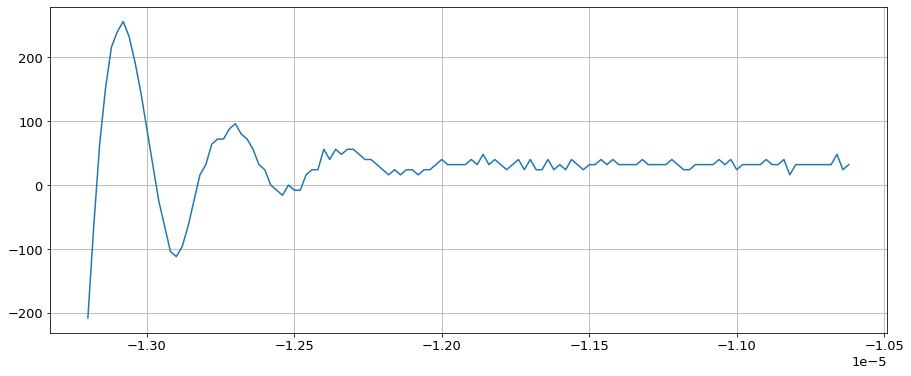

In [28]:
plt.rcParams['figure.figsize'] = [15,6]

plt.plot(tcris,np.fft.ifft(fftCris))
plt.grid()